# Image Classification with Real-Time Data Augmentation

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import split_folder

c:\Users\meet.gajera\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
split_folder.ratio(
    "Patato_all",
    output="imgGenSplit",
    seed=42,
    ratio=(0.7, 0.1, 0.2)
)


Copying (700) of .. train/Potato___Early_blight



100%|██████████| 700/700 [00:00<00:00, 815.63it/s] 



Copying (100) of .. val/Potato___Early_blight



100%|██████████| 100/100 [00:00<00:00, 24856.61it/s]



Copying (200) of .. test/Potato___Early_blight



...

100%|██████████| 700/700 [00:00<00:00, 995.21it/s] 



Copying (100) of .. val/Potato___Late_blight



100%|██████████| 100/100 [00:00<00:00, 5956.89it/s]



Copying (200) of .. test/Potato___Late_blight



100%|██████████| 200/200 [00:00<00:00, 14350.54it/s]


In [ ]:
IMAGE_SIZE = 256
CHANNELS = 3

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8,1.2),
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    'imgGenSplit/train',
    target_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = 32,
    class_mode = 'sparse',
)

Found 1506 images belonging to 3 classes.


In [7]:
for image_batch, label_batch in train_generator:
    print(image_batch.shape)
    break

(32, 256, 256, 3)


In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
)

val_generator = val_datagen.flow_from_directory(
    'imgGenSplit/val',
    target_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = 32,
    class_mode = 'sparse',
)

Found 215 images belonging to 3 classes.


In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    'imgGenSplit/test',
    target_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = 32,
    class_mode = 'sparse',
)

Found 431 images belonging to 3 classes.


In [10]:
input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = tf.keras.Sequential([
    layers.InputLayer(input_shape= input_shape),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1782988491.138594      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782988491.141977      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

In [14]:
history = model.fit(train_generator, 
          batch_size=32, 
          validation_data=val_generator,
          verbose=1, 
          epochs=20
         )

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 557ms/step - accuracy: 0.6169 - loss: 0.7944 - val_accuracy: 0.7023 - val_loss: 0.6699
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 528ms/step - accuracy: 0.6567 - loss: 0.7412 - val_accuracy: 0.5302 - val_loss: 0.8369
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 526ms/step - accuracy: 0.7005 - loss: 0.6674 - val_accuracy: 0.7953 - val_loss: 0.5285
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 529ms/step - accuracy: 0.7258 - loss: 0.6202 - val_accuracy: 0.8465 - val_loss: 0.5110
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 530ms/step - accuracy: 0.7576 - loss: 0.5923 - val_accuracy: 0.8698 - val_loss: 0.4327
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 551ms/step - accuracy: 0.8015 - loss: 0.5102 - val_accuracy: 0.8558 - val_loss: 0.3240
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 531ms/step - accuracy: 0.7497 - loss: 0.6127 - val_accuracy: 0.8698 - val_loss: 0.4239
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 530ms/step - accuracy: 0.7895 - loss: 0.5086 - val_accu

In [16]:
scores = model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.8747 - loss: 0.3196


In [17]:
scores

[0.31959134340286255, 0.874709963798523]

### Plotting the Accuracy and Loss Curves

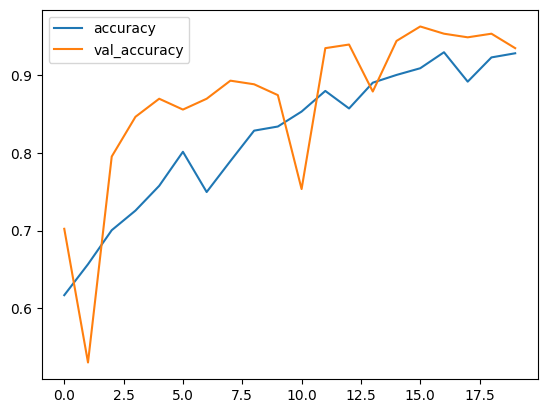

In [18]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

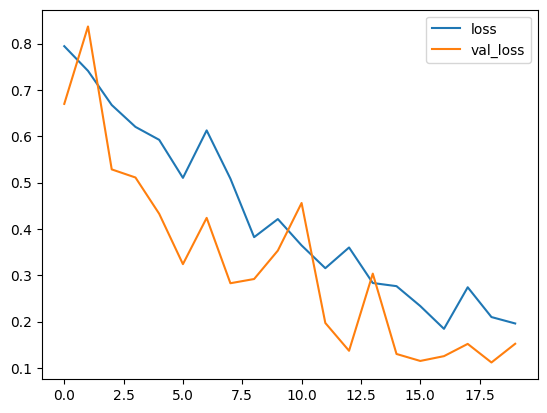

In [19]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

Run prediction on a simple image

first image to predict:
Actual label:  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted Label: Potato___Early_blight


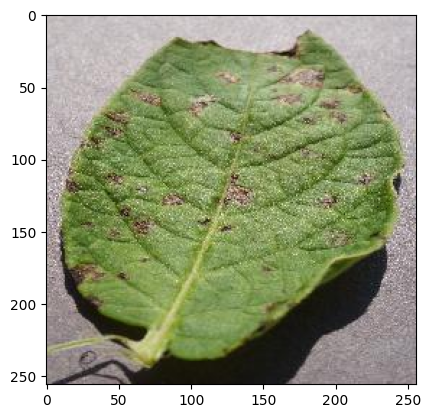

In [34]:
class_names = ['Potato___Early_blight','Potato___Late_blight','Potato___healthy']

import numpy as np

for image_batch, label_batch in test_generator:
    first_image = image_batch[0]
    first_label = int(label_batch[0])

    print("first image to predict:")
    plt.imshow(first_image)
    print("Actual label: ", class_names[first_label])

    batch_prediction = model.predict(image_batch)
    print("Predicted Label:", class_name[np.argmax(batch_prediction[0])])

    break

In [42]:
# write a function for interence

def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(image[i])
    img_array = tf.expand_dims(img_array, 0)   

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidance = round((np.max(predictions[0]))*100, 2)

    return predicted_class, confidance
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


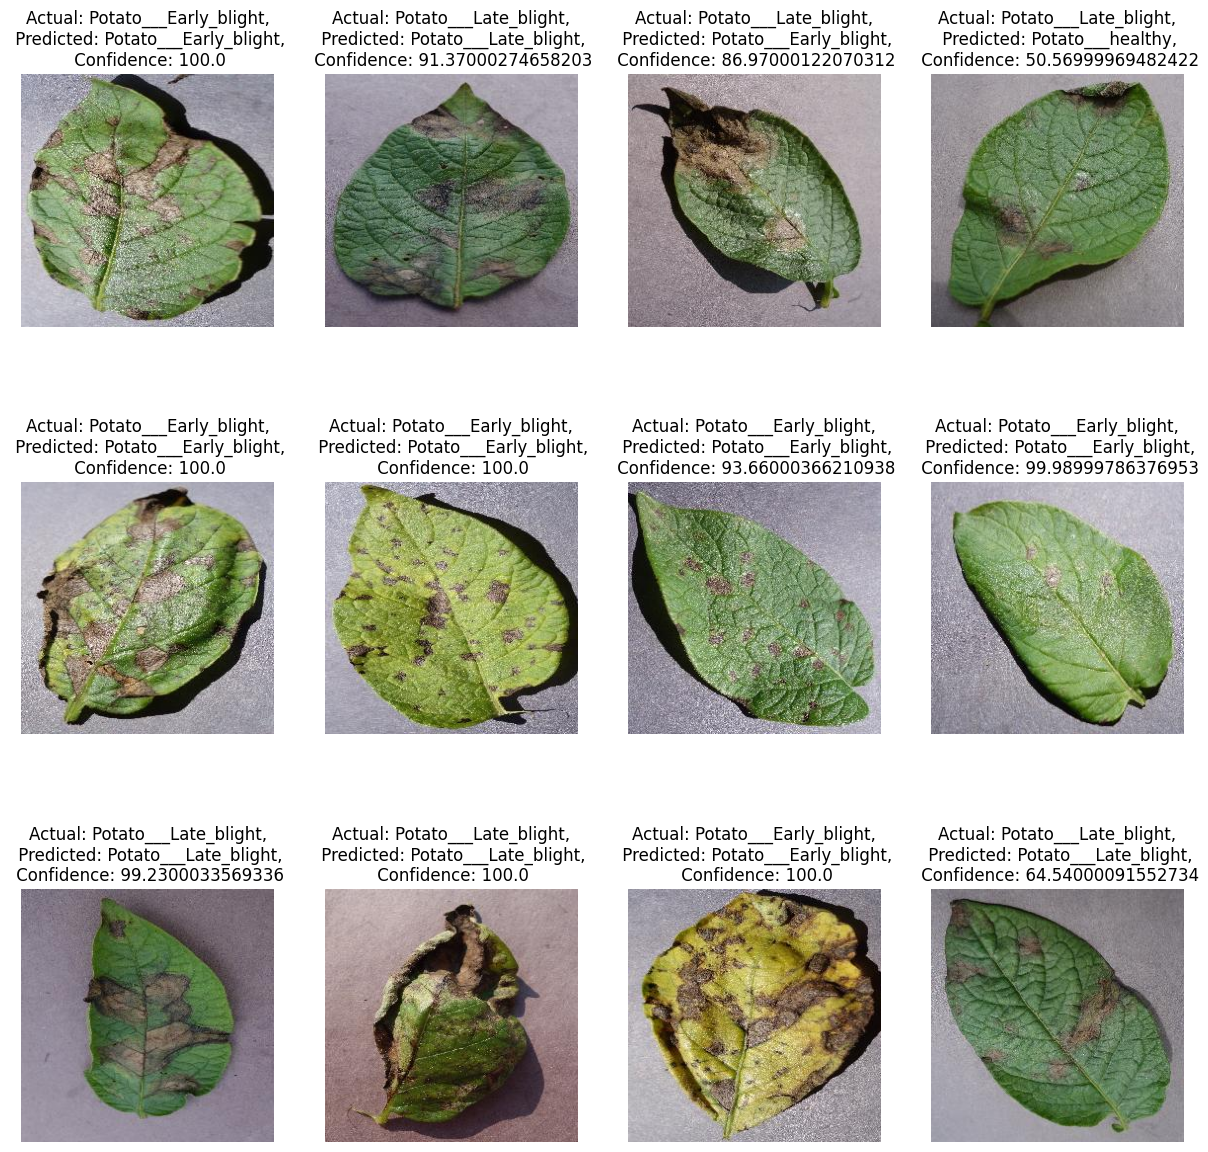

In [46]:
plt.figure(figsize=(15,15))

for image, label in test_generator:
    for i in range(12):
        ax = plt.subplot(3, 4, i+1)
        plt.imshow(image[i])

        predicted_class, confidence = predict(model, image[i])
        actual_class = class_names[int(label[i])]

        plt.title(f'Actual: {actual_class},\n Predicted: {predicted_class},\n Confidence: {confidence}')

        plt.axis('off')

    break